# Phân tích dữ liệu mô tả - Sales_Q1_2024_VN


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sales_Q1_2024_VN.csv')
display(df.head())


,OrderID,OrderDate,ProductID,CustomerID,BranchID,Quantity,Revenue,Profit,Channel
0,2024-Q1-00001,2024-01-02,WM-PANA-11,C034,B04,2,23204000.0,3041000.0,Offline
1,2024-Q1-00002,2024-02-10,WH-ARIST-30,C003,B11,2,6692000.0,1160000.0,Online
2,2024-Q1-00003,2024-01-22,WH-ROSSI-20,C044,B19,2,4410000.0,696000.0,Online
3,2024-Q1-00004,2024-03-17,FAN-ASIA-40,C001,B10,3,1601000.0,208000.0,Offline
4,2024-Q1-00005,2024-02-07,WM-AQUA-9,C026,B19,1,9045000.0,1481000.0,Offline


## 1. Phân phối tần suất (Frequency Distribution)


In [ ]:
cat_cols = ['Channel', 'BranchID', 'ProductID']
for col in cat_cols:
    print(f'\n--- Phân phối tần suất của {col} ---')
    display(df[col].value_counts())
    plt.figure(figsize=(8, 3))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index[:10])
    plt.title(f'Top 10 tần suất của {col}')
    plt.show()


## 2. Thước đo xu hướng trung tâm (Central Tendency)


In [ ]:
num_cols = ['Quantity', 'Revenue', 'Profit']
print('--- Mean (Trung bình) ---')
display(df[num_cols].mean())
print('\n--- Median (Trung vị) ---')
display(df[num_cols].median())
print('\n--- Mode (Yếu vị) ---')
display(df[num_cols].mode().iloc[0])


## 3. Thước đo độ biến thiên (Variability)


In [ ]:
print('--- Range (Khoảng biến thiên) ---')
display(df[num_cols].max() - df[num_cols].min())
print('\n--- Variance (Phương sai) ---')
display(df[num_cols].var())
print('\n--- Standard Deviation (Độ lệch chuẩn) ---')
display(df[num_cols].std())
print('\n--- IQR (Khoảng tứ phân vị) ---')
iqr = df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
display(iqr)


## 4. Thước đo hình thức (Shape)


In [ ]:
print('--- Skewness (Độ nghiêng) ---')
display(df[num_cols].skew())
print('\n--- Kurtosis (Độ nhọn) ---')
display(df[num_cols].kurtosis())

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Phân phối của {col}')
    plt.show()


## 5. Thước đo liên kết (Association)


In [ ]:
print('--- Covariance (Hiệp phương sai) ---')
display(df[num_cols].cov())
print('\n--- Correlation (Hệ số tương quan) ---')
corr_matrix = df[num_cols].corr()
display(corr_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Bản đồ nhiệt Hệ số tương quan')
plt.show()


#### 

In [ ]:
# Đọc dữ liệu 2024 toàn bộ
df_q1_24 = pd.read_csv('Sales_Q1_2024_VN.csv')
df_q2_24 = pd.read_csv('Sales_Q2_2024_VN.csv')
df_q3_24 = pd.read_csv('Sales_Q3_2024_VN.csv')
df_q4_24 = pd.read_csv('Sales_Q4_2024_VN.csv')
df_2024 = pd.concat([df_q1_24, df_q2_24, df_q3_24, df_q4_24], ignore_index=True)

## 6. Phân tích chu kỳ mùa vụ và Dự báo tồn kho (Inventory Forecasting)\n### Gom dữ liệu 2024 và 2025


In [ ]:
# Đọc dữ liệu 2024 toàn bộ
df_q1_24 = pd.read_csv('Sales_Q1_2024_VN.csv')
df_q2_24 = pd.read_csv('Sales_Q2_2024_VN.csv')
df_q3_24 = pd.read_csv('Sales_Q3_2024_VN.csv')
df_q4_24 = pd.read_csv('Sales_Q4_2024_VN.csv')
df_2024 = pd.concat([df_q1_24, df_q2_24, df_q3_24, df_q4_24], ignore_index=True)

# Đọc dữ liệu 2025 (Q1, Q2)
df_q1_25 = pd.read_csv('Sales_Q1_2025_VN.csv')
df_q2_25 = pd.read_csv('Sales_Q2_2025_VN.csv')
df_2025 = pd.concat([df_q1_25, df_q2_25], ignore_index=True)

# Lấy tháng từ OrderDate
df_2024['OrderDate'] = pd.to_datetime(df_2024['OrderDate'])
df_2024['Month'] = df_2024['OrderDate'].dt.month

df_2025['OrderDate'] = pd.to_datetime(df_2025['OrderDate'])
df_2025['Month'] = df_2025['OrderDate'].dt.month



### 6.1. Doanh thu các mặt hàng theo tháng (Năm 2024)\nNhận diện xu hướng mua sắm của các mặt hàng trong năm (vd: máy lạnh mùa nóng).


In [1]:
revenue_by_month_2024 = df_2024.groupby(['ProductID', 'Month'])['Revenue'].sum().reset_index()

# Biểu đồ đường
plt.figure(figsize=(14, 8))
sns.lineplot(data=revenue_by_month_2024, x='Month', y='Revenue', hue='ProductID', marker='o')
plt.title('Doanh Thu Các Mặt Hàng Theo Tháng (Năm 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng Doanh Thu (VNĐ)', fontsize=12)
plt.xticks(range(1, 13))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Biểu đồ nhiệt
pivot_revenue = revenue_by_month_2024.pivot(index='ProductID', columns='Month', values='Revenue').fillna(0)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_revenue, cmap='YlGnBu', annot=False, linewidths=.5)
plt.title('Bản Đồ Nhiệt: Doanh Thu Theo Tháng Năm 2024', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Mã Sản Phẩm', fontsize=12)
plt.tight_layout()
plt.show()



NameError: name 'df_2024' is not defined

### 6.2. So sánh Doanh thu Q1, Q2 giữa 2024 và 2025\nĐánh giá sự thay đổi và tính toán tỷ lệ tăng trưởng.


In [ ]:
# Lọc Q1, Q2 2024
df_q1q2_24 = df_2024[df_2024['Month'].isin([1, 2, 3, 4, 5, 6])].copy()
df_q1q2_24['Year'] = '2024 (Q1+Q2)'

df_q1q2_25 = df_2025.copy()
df_q1q2_25['Year'] = '2025 (Q1+Q2)'

df_compare = pd.concat([df_q1q2_24, df_q1q2_25], ignore_index=True)
compare_revenue = df_compare.groupby(['ProductID', 'Year'])['Revenue'].sum().reset_index()

# Biểu đồ cột so sánh
plt.figure(figsize=(16, 7))
sns.barplot(data=compare_revenue, x='ProductID', y='Revenue', hue='Year', palette='muted')
plt.title('So sánh TỔNG Doanh Thu Q1 & Q2 giữa năm 2024 và 2025', fontsize=14, fontweight='bold')
plt.xlabel('Mã Sản Phẩm', fontsize=12)
plt.ylabel('Tổng Doanh Thu (VNĐ)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Năm')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Tính tỷ lệ tăng trưởng
pivot_compare = compare_revenue.pivot(index='ProductID', columns='Year', values='Revenue').fillna(0)
pivot_compare['Growth Rate (%)'] = ((pivot_compare['2025 (Q1+Q2)'] - pivot_compare['2024 (Q1+Q2)']) / pivot_compare['2024 (Q1+Q2)'] * 100).round(2)
display(pivot_compare.sort_values(by='Growth Rate (%)', ascending=False))



## 7. Phân tích chỉ số Profit Margin (Biên lợi nhuận)\nPhân tích tỷ lệ lợi nhuận cho từng mã sản phẩm dựa trên Revenue và Profit. So sánh giữa các mặt hàng giá trị cao (như máy giặt WM-PANA-11) và các mặt hàng nhỏ (như ấm đun nước KTL-PANA-20).


In [ ]:
# Gộp tất cả dữ liệu để có cái nhìn tổng quan toàn thời gian
df_all = pd.concat([df_2024, df_2025], ignore_index=True)

# Tính tổng Doanh thu và Lợi nhuận theo từng mã sản phẩm
profit_analysis = df_all.groupby('ProductID')[['Revenue', 'Profit']].sum().reset_index()

# Tính Profit Margin (%)
profit_analysis['Profit_Margin_%'] = (profit_analysis['Profit'] / profit_analysis['Revenue'] * 100).round(2)

# Sắp xếp theo Profit Margin
profit_analysis = profit_analysis.sort_values('Profit_Margin_%', ascending=False).reset_index(drop=True)

# Hiển thị bảng tổng hợp
display(profit_analysis)

# Trực quan hóa Biên lợi nhuận
plt.figure(figsize=(16, 6))
# Dùng hue và legend=False để tránh cảnh báo palette
sns.barplot(data=profit_analysis, x='ProductID', y='Profit_Margin_%', hue='ProductID', palette='viridis')
plt.legend([],[], frameon=False)
plt.title('Biên Lợi Nhuận (Profit Margin %) Của Từng Sản Phẩm', fontsize=14, fontweight='bold')
plt.xlabel('Mã Sản Phẩm', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Highlight WM-PANA-11 và KTL-PANA-20
highlight_products = ['WM-PANA-11', 'KTL-PANA-20']
for i, row in profit_analysis.iterrows():
    if row['ProductID'] in highlight_products:
        plt.text(i, row['Profit_Margin_%'] + 0.5, f"{row['Profit_Margin_%']}%", 
                 color='red', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# So sánh trực tiếp 2 sản phẩm đại diện
comp_target = profit_analysis[profit_analysis['ProductID'].isin(highlight_products)]
print("--- So sánh Biên lợi nhuận: WM-PANA-11 (Máy giặt) vs KTL-PANA-20 (Ấm đun nước) ---")
display(comp_target)



## 8. Định hướng Chiến lược Marketing (Revenue vs Profit Margin)\nSử dụng biểu đồ Scatter Plot để phân loại sản phẩm thành 4 nhóm dựa trên Doanh thu (Giá trị) và Biên lợi nhuận (Hiệu quả). Từ đó đưa ra chiến lược ưu tiên Marketing.


In [ ]:
# Sử dụng lại df_all chứa dữ liệu 2024 & 2025
strategy_df = df_all.groupby('ProductID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

# Tính Profit Margin
strategy_df['Profit_Margin_%'] = (strategy_df['Total_Profit'] / strategy_df['Total_Revenue'] * 100).round(2)

# Xác định ngưỡng trung bình
avg_revenue = strategy_df['Total_Revenue'].mean()
avg_margin = strategy_df['Profit_Margin_%'].mean()

# Phân loại 4 góc phần tư (Quadrants)
def categorize_product(row):
    if row['Total_Revenue'] >= avg_revenue and row['Profit_Margin_%'] >= avg_margin:
        return 'Ngôi sao (Nên đẩy mạnh)'
    elif row['Total_Revenue'] >= avg_revenue and row['Profit_Margin_%'] < avg_margin:
        return 'Bò sữa (Tạo LN ổn định, tối ưu phí)'
    elif row['Total_Revenue'] < avg_revenue and row['Profit_Margin_%'] >= avg_margin:
        return 'Tiềm năng (Cần marketing tăng Vol)'
    else:
        return 'Chó mực (Cân nhắc loại bỏ/Giảm)'

strategy_df['Category'] = strategy_df.apply(categorize_product, axis=1)

# Trực quan hóa Scatter Plot
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=strategy_df, 
    x='Total_Revenue', 
    y='Profit_Margin_%', 
    hue='Category', 
    size='Total_Profit', 
    sizes=(100, 2000), 
    alpha=0.7, 
    palette='Set1'
)

# Vẽ đường trung bình chia 4 góc phần tư
plt.axvline(avg_revenue, color='gray', linestyle='--')
plt.axhline(avg_margin, color='gray', linestyle='--')

# Gắn tên cho các sản phẩm
for i in range(strategy_df.shape[0]):
    plt.text(x=strategy_df['Total_Revenue'][i], 
             y=strategy_df['Profit_Margin_%'][i] + 0.5, 
             s=strategy_df['ProductID'][i], 
             fontdict=dict(color='black', size=9),
             ha='center')

plt.title('Ma trận Chiến lược: Doanh Thu vs Biên Lợi Nhuận', fontsize=16, fontweight='bold')
plt.xlabel('Tổng Doanh Thu (VNĐ)', fontsize=12)
plt.ylabel('Biên Lợi Nhuận (Profit Margin %)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Hiển thị Tóm tắt Chiến lược
print("--- KHUYẾN NGHỊ CHIẾN LƯỢC TỪ MA TRẬN ---\n")
for cat in strategy_df['Category'].unique():
    prods = strategy_df[strategy_df['Category'] == cat]['ProductID'].tolist()
    print(f"[{cat}]: {', '.join(prods)}")



## 9. Phân tích hiệu quả Kênh bán hàng (Channel Performance)\nĐánh giá sự dịch chuyển hành vi người tiêu dùng giữa kênh Online và Offline qua các quý. Đặc biệt xem xét các sản phẩm đắt tiền (máy lạnh, máy giặt) xem khách hàng ưu tiên mua ở đâu.


In [ ]:
# Thêm thông tin Quý (Quarter) và Năm (Year) vào mức hiển thị, ví dụ '2024-Q1'
df_all['OrderDate'] = pd.to_datetime(df_all['OrderDate'])
df_all['Quarter'] = df_all['OrderDate'].dt.to_period('Q').astype(str)

# 9.1. Thống kê tỷ lệ đơn hàng và lợi nhuận giữa Online và Offline qua các Quý
channel_trend = df_all.groupby(['Quarter', 'Channel']).agg(
    Orders=('OrderID', 'count'),
    Profit=('Profit', 'sum')
).reset_index()

# Biểu đồ xu hướng Đơn hàng theo Kênh qua các Quý
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.lineplot(data=channel_trend, x='Quarter', y='Orders', hue='Channel', marker='o', linewidth=2)
plt.title('Số lượng Đơn hàng: Online vs Offline', fontsize=12, fontweight='bold')
plt.xlabel('Quý', fontsize=10)
plt.ylabel('Số lượng Đơn hàng', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Biểu đồ xu hướng Lợi nhuận theo Kênh qua các Quý
plt.subplot(1, 2, 2)
sns.lineplot(data=channel_trend, x='Quarter', y='Profit', hue='Channel', marker='s', linewidth=2)
plt.title('Lợi Nhuận: Online vs Offline', fontsize=12, fontweight='bold')
plt.xlabel('Quý', fontsize=10)
plt.ylabel('Lợi Nhuận (VNĐ)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 9.2. Phân tích hành vi mua các sản phẩm đắt tiền theo Kênh
# Tính giá trung bình mỗi sản phẩm: Revenue / Quantity
df_all['Unit_Price'] = df_all['Revenue'] / df_all['Quantity']
avg_price_by_product = df_all.groupby('ProductID')['Unit_Price'].mean().sort_values(ascending=False)

# Xác định Top 5 sản phẩm đắt tiền nhất (máy lạnh, máy giặt, v.v)
high_value_products = avg_price_by_product.head(5).index.tolist()
print(f"Top 5 sản phẩm có đơn giá cao nhất: {high_value_products}")

# Lọc dữ liệu nhóm sản phẩm đắt tiền này
df_high_value = df_all[df_all['ProductID'].isin(high_value_products)]

# Thống kê lượng mua (Orders) theo kênh của nhóm đắt tiền
high_value_channel = df_high_value.groupby(['ProductID', 'Channel']).agg(Orders=('OrderID', 'count')).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=high_value_channel, x='ProductID', y='Orders', hue='Channel', palette='Set2')
plt.title('Hành vi Chọn Kênh đối với Sản Phẩm Đắt Tiền (Máy giặt, Máy lạnh...)', fontsize=14, fontweight='bold')
plt.xlabel('Mã Sản Phẩm', fontsize=12)
plt.ylabel('Số lượng Đơn hàng', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Kênh bán')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Hiển thị bảng tỷ trọng Online/Offline cho nhóm Đắt tiền
pivot_hv = high_value_channel.pivot(index='ProductID', columns='Channel', values='Orders').fillna(0)
pivot_hv['Total'] = pivot_hv['Offline'] + pivot_hv['Online']
pivot_hv['Online_Ratio_%'] = (pivot_hv['Online'] / pivot_hv['Total'] * 100).round(1)
pivot_hv['Offline_Ratio_%'] = (pivot_hv['Offline'] / pivot_hv['Total'] * 100).round(1)
display(pivot_hv.sort_values(by='Online_Ratio_%', ascending=False))



## 10. Phân khúc Khách hàng & Bán chéo (Cross-selling Insights)\nPhân tích khách hàng có giá trị cao dựa trên CustomerID và đề xuất gói combo bán chéo (ví dụ: khách mua máy lạnh có xu hướng mua máy lọc không khí).


--- Top 10 Khách hàng mang lại Doanh thu lớn nhất ---


,CustomerID,Total_Revenue,Total_Orders
31,C032,386437000.0,47
98,C099,360171000.0,42
0,C001,354106000.0,58
24,C025,344977000.0,54
7,C008,337233000.0,49
45,C046,329505000.0,46
32,C033,326574000.0,45
83,C084,311092000.0,47
56,C057,296776000.0,50
59,C060,293814000.0,41


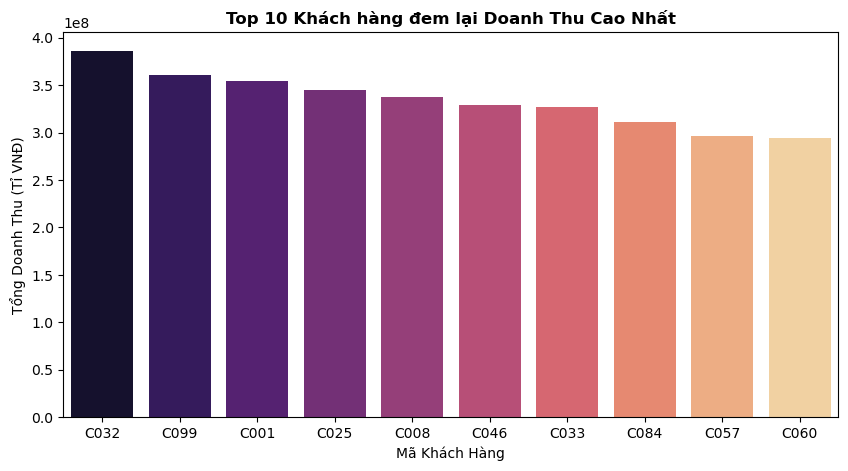

Tổng số khách hàng từng mua Máy điều hòa (AC): 100
Số khách hàng mua cả Máy điều hòa và Máy lọc không khí: 96
Tỷ lệ mua chéo (Mua AC cũng kèm/sau đó mua Máy lọc không khí): 96.00%


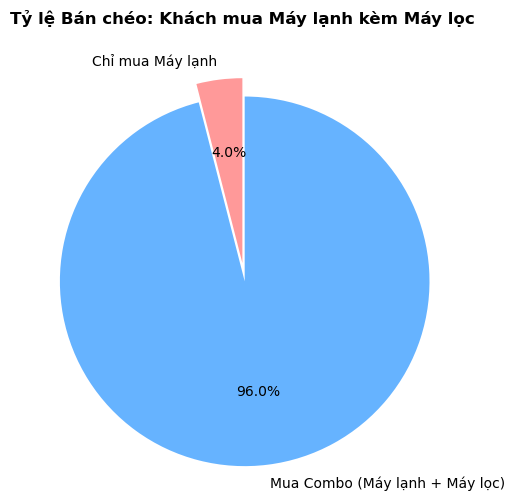


--- ĐỀ XUẤT HÀNH ĐỘNG DÀNH CHO MARKETING ---
=> Tỷ lệ Cross-selling rất khả quan. Giải pháp: Tung mã giảm giá tự động 'Combo Máy lạnh + Máy lọc không khí' để kích cầu thêm, tăng AOV (giá trị giỏ hàng trung bình).


In [71]:
# 10.1. Phân khúc khách hàng giá trị cao (Top 10 Khách hàng theo Doanh thu)
customer_value = df_all.groupby('CustomerID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('OrderID', 'nunique')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

top_customers = customer_value.head(10)
print("--- Top 10 Khách hàng mang lại Doanh thu lớn nhất ---")
display(top_customers)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_customers, x='CustomerID', y='Total_Revenue', palette='magma')
plt.title('Top 10 Khách hàng đem lại Doanh Thu Cao Nhất', fontsize=12, fontweight='bold')
plt.xlabel('Mã Khách Hàng', fontsize=10)
plt.ylabel('Tổng Doanh Thu (Tỉ VNĐ)', fontsize=10)
plt.show()

# 10.2. Phân tích Bán chéo (Cross-selling) - Gói Combo Điều hòa (AC) & Máy lọc (AIR-PURI)
# Lọc khách hàng đã mua mặt hàng chứa 'AC' (máy lạnh)
ac_customers = df_all[df_all['ProductID'].str.contains('AC')]['CustomerID'].unique()

print(f"Tổng số khách hàng từng mua Máy điều hòa (AC): {len(ac_customers)}")

# Lọc trong nhóm này những ai đã mua 'AIR-PURI' (Máy lọc không khí)
air_purchases = df_all[(df_all['CustomerID'].isin(ac_customers)) & (df_all['ProductID'].str.contains('AIR-PURI'))]
cross_buyers = air_purchases['CustomerID'].nunique()
print(f"Số khách hàng mua cả Máy điều hòa và Máy lọc không khí: {cross_buyers}")

# Tính tỷ lệ Cross-selling
cross_rate = (cross_buyers / len(ac_customers)) * 100 if len(ac_customers) > 0 else 0
print(f"Tỷ lệ mua chéo (Mua AC cũng kèm/sau đó mua Máy lọc không khí): {cross_rate:.2f}%")

labels = ['Chỉ mua Máy lạnh', 'Mua Combo (Máy lạnh + Máy lọc)']
sizes = [len(ac_customers) - cross_buyers, cross_buyers]
colors = ['#ff9999','#66b3ff']

if sum(sizes) > 0:
    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0, 0.1))
    plt.title('Tỷ lệ Bán chéo: Khách mua Máy lạnh kèm Máy lọc', fontsize=12, fontweight='bold')
    plt.show()

# Đề xuất dựa trên dữ liệu
print("\n--- ĐỀ XUẤT HÀNH ĐỘNG DÀNH CHO MARKETING ---")
if cross_rate > 5:
    print("=> Tỷ lệ Cross-selling rất khả quan. Giải pháp: Tung mã giảm giá tự động 'Combo Máy lạnh + Máy lọc không khí' để kích cầu thêm, tăng AOV (giá trị giỏ hàng trung bình).")
else:
    print("=> Tỷ lệ Cross-selling còn thấp so với tiềm năng. Giải pháp: Lọc danh sách khách hàng đã mua AC năm trước gửi chiến dịch Email/Zalo ZNS giới thiệu Máy lọc không khí với giá ưu đãi đặc biệt.")



### 11. Phân tích Hiệu suất Chi nhánh (Branch Intelligence)\\nĐánh giá sở thích sản phẩm theo vùng miền (các chi nhánh B01-B20) nhằm tối ưu điều phối tồn kho. Ví dụ: Phát hiện chi nhánh B11 chuộng máy lọc không khí, trong khi B19 tiêu thụ mạnh máy nước nóng.


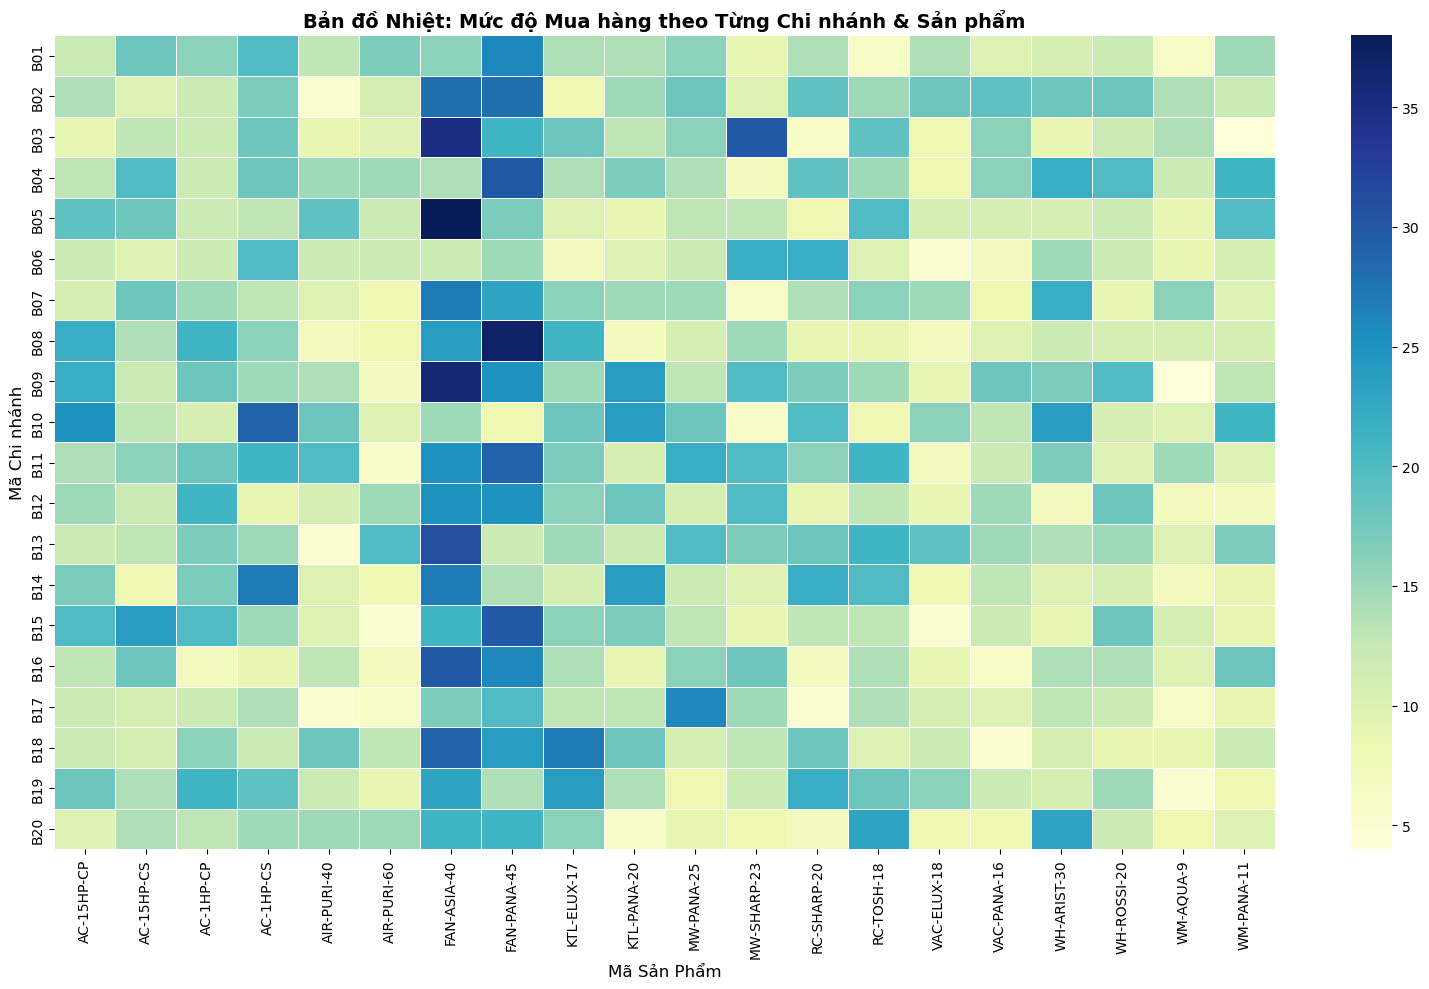

In [32]:
# Thống kê tổng Số lượng bán ra của từng sản phẩm tại từng chi nhánh
branch_product_sales = df_all.groupby(['BranchID', 'ProductID'])['Quantity'].sum().reset_index()

# 11.1 Trực quan hóa Heatmap toàn cảnh
# Pivot table để dễ so sánh: Dòng = Chi nhánh, Cột = Sản phẩm, Giá trị = Số lượng
pivot_branch = branch_product_sales.pivot(index='BranchID', columns='ProductID', values='Quantity').fillna(0)
plt.figure(figsize=(16, 10))
sns.heatmap(pivot_branch, cmap='YlGnBu', linewidths=0.5)
plt.title('Bản đồ Nhiệt: Mức độ Mua hàng theo Từng Chi nhánh & Sản phẩm', fontsize=14, fontweight='bold')
plt.xlabel('Mã Sản Phẩm', fontsize=12)
plt.ylabel('Mã Chi nhánh', fontsize=12)
plt.tight_layout()
plt.show()

In [33]:

# 11.2 Đi sâu vào sự sai khác giữa B11 (Máy lọc không khí) vs B19 (Máy nước nóng)
focus_branches = ['B11', 'B19']

# Lọc các danh mục Sản phẩm chứa 'AIR-PURI' hoặc 'WH'
focus_products = df_all[df_all['ProductID'].str.contains('AIR-PURI|WH-')]['ProductID'].unique()

focus_data = branch_product_sales[
    (branch_product_sales['BranchID'].isin(focus_branches)) & 
    (branch_product_sales['ProductID'].isin(focus_products))
]

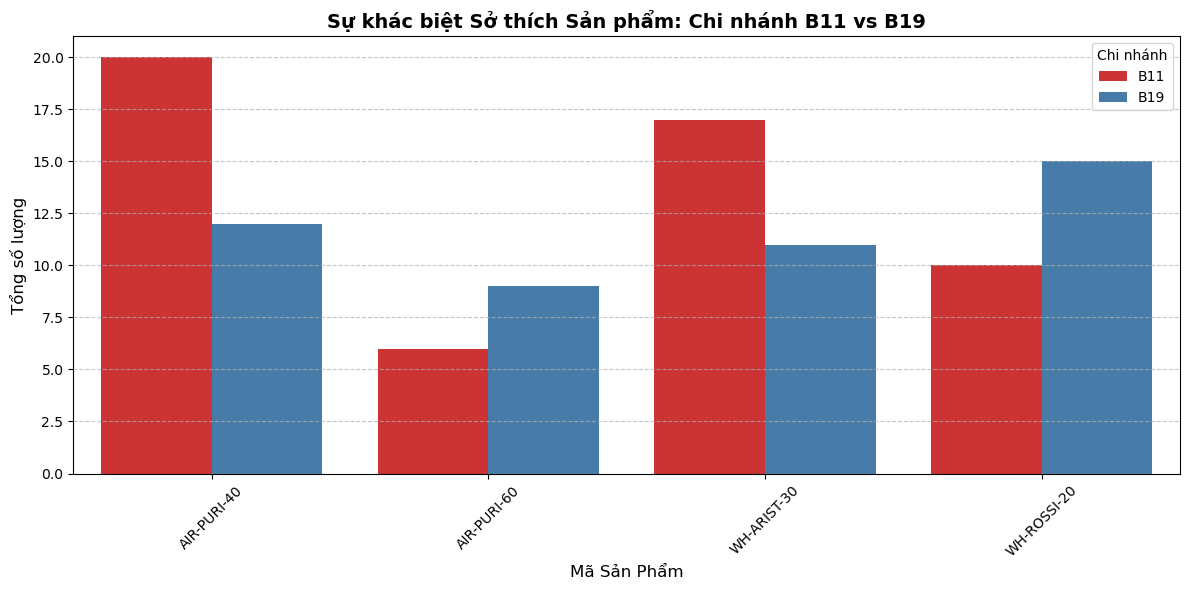

In [34]:

plt.figure(figsize=(12, 6))
sns.barplot(data=focus_data, x='ProductID', y='Quantity', hue='BranchID', palette='Set1')
plt.title('Sự khác biệt Sở thích Sản phẩm: Chi nhánh B11 vs B19', fontsize=14, fontweight='bold')
plt.xlabel('Mã Sản Phẩm', fontsize=12)
plt.ylabel('Tổng số lượng', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Chi nhánh')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [36]:

# 11.3 Đề xuất Điều phối Tồn kho
print("\n--- ĐIỀU PHỐI TỒN KHO THÔNG MINH ---")
top_products_per_branch = branch_product_sales.loc[branch_product_sales.groupby('BranchID')['Quantity'].idxmax()]
print("Sản phẩm Best-Seller tại một số chi nhánh tiêu biểu:")
display(top_products_per_branch[top_products_per_branch['BranchID'].isin(['B01', 'B11', 'B19', 'B20'])])

print("\n=> Khuyến nghị Chiến lược Tồn kho & Logistics:")
print("1. Đặc thù vùng miền: Kho trung tâm NÊN ưu tiên phân bổ tỷ trọng lớn các dòng 'AIR-PURI' (Máy lọc) thẳng đến chi nhánh B11 ngay từ đầu kỳ.")
print("2. Tối ưu chi phí luân chuyển: Các dòng Máy nước nóng ('WH-') nên được găm hàng chủ lực tại B19.")
print("3. Cứu nét chéo nhanh (Cross-transfer): Nếu B19 hụt hàng máy nước nóng gấp, có thể kiểm tra kho của B11 (do tại đây WH ế/bán chậm) để yêu cầu luân chuyển nội bộ thay vì chờ đặt thêm từ Head Quarter, giúp tránh tốn phí lưu kho dài hạn.")



--- ĐIỀU PHỐI TỒN KHO THÔNG MINH ---
Sản phẩm Best-Seller tại một số chi nhánh tiêu biểu:


,BranchID,ProductID,Quantity
7,B01,FAN-PANA-45,26
207,B11,FAN-PANA-45,29
368,B19,KTL-ELUX-17,24
393,B20,RC-TOSH-18,23



=> Khuyến nghị Chiến lược Tồn kho & Logistics:
1. Đặc thù vùng miền: Kho trung tâm NÊN ưu tiên phân bổ tỷ trọng lớn các dòng 'AIR-PURI' (Máy lọc) thẳng đến chi nhánh B11 ngay từ đầu kỳ.
2. Tối ưu chi phí luân chuyển: Các dòng Máy nước nóng ('WH-') nên được găm hàng chủ lực tại B19.
3. Cứu nét chéo nhanh (Cross-transfer): Nếu B19 hụt hàng máy nước nóng gấp, có thể kiểm tra kho của B11 (do tại đây WH ế/bán chậm) để yêu cầu luân chuyển nội bộ thay vì chờ đặt thêm từ Head Quarter, giúp tránh tốn phí lưu kho dài hạn.


### Lợi nhuận gộp của quý 1 năm 2025 thay đổi như thế nào ?

In [37]:
import pandas as pd

df_q1_24 = pd.read_csv('Sales_Q1_2024_VN.csv')
profit_q1_24 = df_q1_24['Profit'].sum()

df_q1_25 = pd.read_csv('Sales_Q1_2025_VN.csv')
profit_q1_25 = df_q1_25['Profit'].sum()

change = profit_q1_25 - profit_q1_24
pct = (change / profit_q1_24) * 100

print(f"Lợi nhuận Q1/2024: {profit_q1_24:,.0f} VNĐ")
print(f"Lợi nhuận Q1/2025: {profit_q1_25:,.0f} VNĐ")
print(f"Thay đổi tuyệt đối: {change:,.0f} VNĐ")
print(f"Tỷ lệ thay đổi: {pct:.2f}%")


Lợi nhuận Q1/2024: 496,832,000 VNĐ
Lợi nhuận Q1/2025: 498,151,000 VNĐ
Thay đổi tuyệt đối: 1,319,000 VNĐ
Tỷ lệ thay đổi: 0.27%


### 12. Tổng kết So sánh Tổng Doanh thu & Lợi nhuận Q1/2024 vs Q1/2025\\nĐánh giá nhanh tình hình tăng trưởng tổng quan của toàn doanh nghiệp trong Quý 1 hai năm liên tiếp.

In [44]:
# Lọc dữ liệu riêng cho Q1/2024 và Q1/2025
df_q1_24_only = df_all[df_all['Quarter'] == '2024Q1']
df_q1_25_only = df_all[df_all['Quarter'] == '2025Q1']

# Tính toán
rev_q1_24 = df_q1_24_only['Revenue'].sum()
rev_q1_25 = df_q1_25_only['Revenue'].sum()
prof_q1_24 = df_q1_24_only['Profit'].sum()
prof_q1_25 = df_q1_25_only['Profit'].sum()

# Tỷ lệ thay đổi
rev_change = (rev_q1_25 - rev_q1_24) / rev_q1_24 * 100 if rev_q1_24 > 0 else 0
prof_change = (prof_q1_25 - prof_q1_24) / prof_q1_24 * 100 if prof_q1_24 > 0 else 0

summary_df = pd.DataFrame({
    'Chỉ tiêu': ['Tổng Doanh Thu (VNĐ)', 'Lợi Nhuận Gộp (VNĐ)'],
    'Q1/2024': [rev_q1_24, prof_q1_24],
    'Q1/2025': [rev_q1_25, prof_q1_25],
    'Thay đổi Tuyệt đối': [rev_q1_25 - rev_q1_24, prof_q1_25 - prof_q1_24],
    'Tăng trưởng (%)': [rev_change, prof_change]
})

In [45]:

print("--- BẢNG SO SÁNH TỔNG QUAN TĂNG TRƯỞNG QUÝ 1 (2024 vs 2025) ---")
display(summary_df.style.format({
    'Q1/2024': '{:,.0f}',
    'Q1/2025': '{:,.0f}',
    'Thay đổi Tuyệt đối': '{:,.0f}',
    'Tăng trưởng (%)': '{:.2f}%'
}))


--- BẢNG SO SÁNH TỔNG QUAN TĂNG TRƯỞNG QUÝ 1 (2024 vs 2025) ---


,Chỉ tiêu,Q1/2024,Q1/2025,Thay đổi Tuyệt đối,Tăng trưởng (%)
0,Tổng Doanh Thu (VNĐ),"3,302,500,000","3,330,081,000","27,581,000",0.84%
1,Lợi Nhuận Gộp (VNĐ),"496,832,000","498,151,000","1,319,000",0.27%


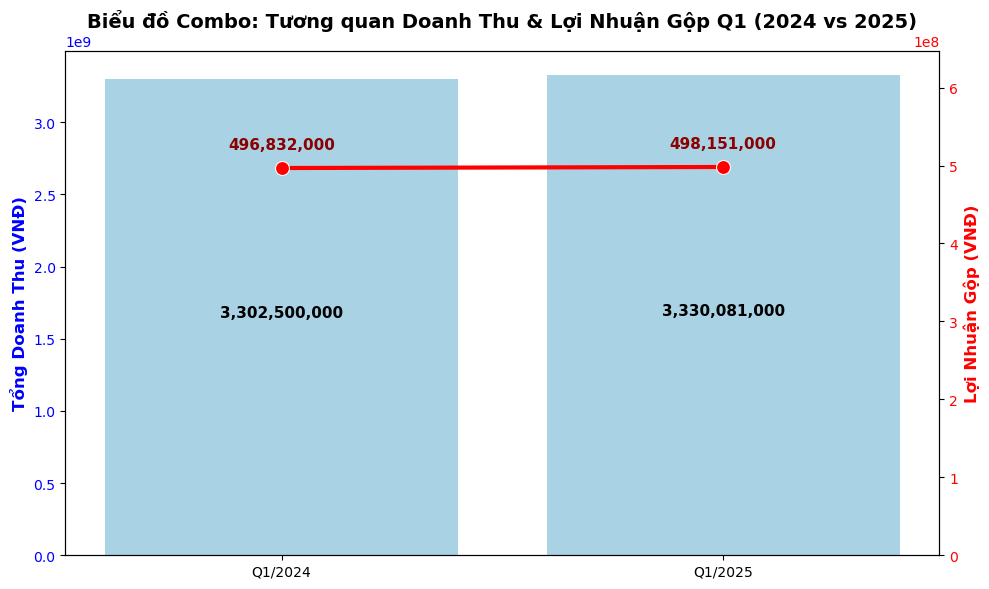

=> Lợi nhuận gộp Q1/2025 TĂNG MẠNH 0.27% so với cùng kỳ năm ngoái.


In [46]:

# Trực quan hóa Biểu đồ Combo (Combo Chart) cho Doanh Thu và Lợi Nhuận
fig, ax1 = plt.subplots(figsize=(10, 6))

# Trục trái: Cột Doanh Thu
quarters = ['Q1/2024', 'Q1/2025']
revenues = [rev_q1_24, rev_q1_25]
profits = [prof_q1_24, prof_q1_25]

# Vẽ Cột Doanh Thu trên trục 1
sns.barplot(x=quarters, y=revenues, color='skyblue', alpha=0.8, ax=ax1)
ax1.set_ylabel('Tổng Doanh Thu (VNĐ)', color='blue', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue')
for i, v in enumerate(revenues):
    ax1.text(i, v * 0.5, f"{v:,.0f}", color='black', ha='center', fontweight='bold', fontsize=11)

# Trục phải: Đường Lợi Nhuận
ax2 = ax1.twinx()
# Vẽ Đường Lợi nhuận trên trục 2
sns.lineplot(x=quarters, y=profits, color='red', marker='o', linewidth=3, markersize=10, ax=ax2)
ax2.set_ylabel('Lợi Nhuận Gộp (VNĐ)', color='red', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')
# Phóng limit trục y số 2 một chút để số không bị đè đỉnh biểu đồ
ax2.set_ylim(bottom=0, top=max(profits)*1.3)
for i, v in enumerate(profits):
    ax2.text(i, v * 1.05, f"{v:,.0f}", color='darkred', ha='center', fontweight='bold', fontsize=11)

plt.title('Biểu đồ Combo: Tương quan Doanh Thu & Lợi Nhuận Gộp Q1 (2024 vs 2025)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

if prof_change > 0:
    print(f"=> Lợi nhuận gộp Q1/2025 TĂNG MẠNH {prof_change:.2f}% so với cùng kỳ năm ngoái.")
else:
    print(f"=> Lợi nhuận gộp Q1/2025 CÓ DẤU HIỆU SUY GIẢM {prof_change:.2f}% so với cùng kỳ năm ngoái.")

### 13. Dự báo Xu hướng Tồn kho Mùa vụ (Các Quý tiếp theo năm 2025)\\nDựa trên dữ liệu doanh số lịch sử của năm 2024 và thiết lập tỷ lệ tăng trưởng trong nửa đầu năm, Hệ thống sẽ dự phóng lượng hàng tồn kho (Quantity) cần chuẩn bị cho Quý 3 và Quý 4 của năm 2025, giúp Cửa hàng lên kế hoạch nhập khẩu."


In [47]:
import numpy as np

# Gom dữ liệu để tính số lượng bán ra từng Quý
qty_by_quarter = df_all.groupby(['ProductID', 'Quarter'])['Quantity'].sum().reset_index()

# Tách dữ liệu thành H1 (Q1+Q2) và H2 (Q3+Q4)
q_qty = qty_by_quarter.pivot(index='ProductID', columns='Quarter', values='Quantity').fillna(0)

# Kiểm tra nếu chưa đủ cả 4 quý 2024 thì điền tạm 0
for q in ['2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2']:
    if q not in q_qty.columns:
        q_qty[q] = 0

In [48]:

# Tính tổng H1 2024 và H1 2025
q_qty['H1_2024'] = q_qty['2024Q1'] + q_qty['2024Q2']
q_qty['H1_2025'] = q_qty['2025Q1'] + q_qty['2025Q2']


In [49]:

# Tính tỷ lệ tăng trưởng nửa đầu năm (H1 Growth Rate)
# Dùng tỷ lệ này làm Hệ số Dự báo cho các Quý Nửa cuối năm (H2)
# Khống chế tỷ lệ từ 0.5 (giảm tối đa 50%) đến 2.0 (tăng tối đa 100%) để tránh bị outlier do sản phẩm mới
q_qty['Growth_Rate'] = (q_qty['H1_2025'] / q_qty['H1_2024']).replace([np.inf, -np.inf], 1).fillna(1)
q_qty['Growth_Rate'] = q_qty['Growth_Rate'].clip(lower=0.5, upper=2.0)

# Dự báo Tồn kho Q3/2025 và Q4/2025
q_qty['Forecast_2025Q3'] = np.ceil(q_qty['2024Q3'] * q_qty['Growth_Rate'])
q_qty['Forecast_2025Q4'] = np.ceil(q_qty['2024Q4'] * q_qty['Growth_Rate'])


In [51]:

# Chuyển đổi Output cho dễ xem
forecast_cols = ['2024Q3', 'Forecast_2025Q3', '2024Q4', 'Forecast_2025Q4']
forecast_df = q_qty[forecast_cols].copy()
forecast_df['Expected_YoY_Growth_%'] = ((q_qty['Growth_Rate'] - 1) * 100).round(1)

print("--- BẢNG DỰ BÁO TỒN KHO LOGISTICS CHO Q3 & Q4 NĂM 2025 (Theo Sản phẩm) ---")
display(forecast_df.sort_values(by='Forecast_2025Q3', ascending=False).head(10))


--- BẢNG DỰ BÁO TỒN KHO LOGISTICS CHO Q3 & Q4 NĂM 2025 (Theo Sản phẩm) ---


Quarter,2024Q3,Forecast_2025Q3,2024Q4,Forecast_2025Q4,Expected_YoY_Growth_%
ProductID,,,,,
FAN-PANA-45,120,112.0,43,41.0,-6.8
FAN-ASIA-40,111,96.0,63,55.0,-14.0
AC-15HP-CS,61,69.0,20,23.0,12.4
AC-1HP-CS,60,60.0,32,32.0,-0.8
AC-1HP-CP,53,59.0,24,27.0,11.2
AC-15HP-CP,56,58.0,35,37.0,2.9
RC-SHARP-20,44,56.0,46,59.0,26.7
KTL-PANA-20,49,52.0,44,47.0,5.2
WM-PANA-11,42,51.0,48,59.0,21.1


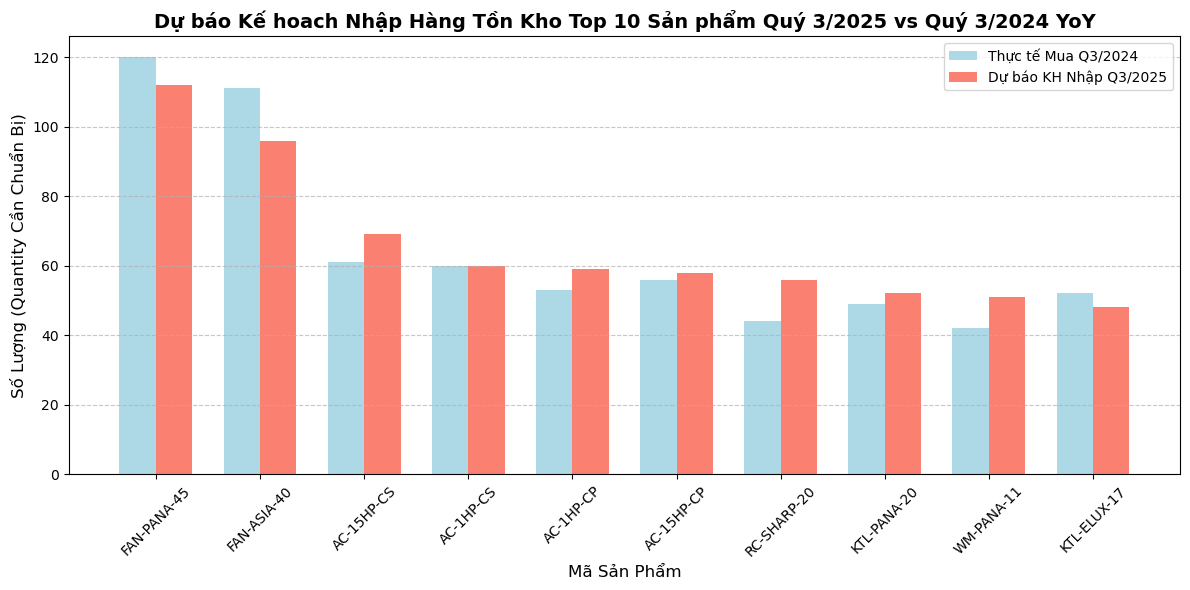

In [52]:

# Trực quan hóa Top 10 sản phẩm có nhu cầu Tồn kho cao nhất Quý 3/2025
top10_forecast_q3 = forecast_df.sort_values(by='Forecast_2025Q3', ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))

x = np.arange(len(top10_forecast_q3['ProductID']))
width = 0.35

plt.bar(x - width/2, top10_forecast_q3['2024Q3'], width, label='Thực tế Mua Q3/2024', color='lightblue')
plt.bar(x + width/2, top10_forecast_q3['Forecast_2025Q3'], width, label='Dự báo KH Nhập Q3/2025', color='salmon')

plt.title('Dự báo Kế hoach Nhập Hàng Tồn Kho Top 10 Sản phẩm Quý 3/2025 vs Quý 3/2024 YoY', fontsize=14, fontweight='bold')
plt.xlabel('Mã Sản Phẩm', fontsize=12)
plt.ylabel('Số Lượng (Quantity Cần Chuẩn Bị)', fontsize=12)
plt.xticks(x, top10_forecast_q3['ProductID'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [54]:

# Đưa ra Actionable Insight
print("\n=> Insight Quản trị Tồn kho (Supply Chain Management):")
print("- Dựa trên hệ số tăng trưởng thực tế của Nửa đầu năm (H1), Biểu đồ đã thể hiện dự phóng số lượng nhập cho Mùa vụ nửa cuối năm.")
print("- Các mặt hàng có cột Đỏ (2025) cao hơn rõ rệt: Đại diện thu mua (Procurement) cần ứng vốn và Chốt đàm phán số nguyên liệu dự trữ ngay hôm nay với các Nhà cung cấp (Vender) để tránh đứt gẫy chuỗi cung ứng mùa cao điểm.")



=> Insight Quản trị Tồn kho (Supply Chain Management):
- Dựa trên hệ số tăng trưởng thực tế của Nửa đầu năm (H1), Biểu đồ đã thể hiện dự phóng số lượng nhập cho Mùa vụ nửa cuối năm.
- Các mặt hàng có cột Đỏ (2025) cao hơn rõ rệt: Đại diện thu mua (Procurement) cần ứng vốn và Chốt đàm phán số nguyên liệu dự trữ ngay hôm nay với các Nhà cung cấp (Vender) để tránh đứt gẫy chuỗi cung ứng mùa cao điểm.


### 14. Phân khúc Khách hàng theo RFM Model (Recency - Frequency - Monetary)\\nRFM giúp phân vùng những Khách Hàng nào là VIP, những ai có Khả năng Sắp Rời bỏ (Churn Risk) dựa trên Giá trị Đem Lại (Giao dịch)."

In [55]:
import datetime as dt

# Giả định ngày phân tích là 1 ngày sau ngày giao dịch cuối cùng trong data
snapshot_date = df_all['OrderDate'].max() + dt.timedelta(days=1)

# Tính RFM cho mỗi khách hàng
rfm = df_all.groupby('CustomerID').agg({
    'OrderDate': lambda x: (snapshot_date - x.max()).days,
    'OrderID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={'OrderDate': 'Recency', 'OrderID': 'Frequency', 'Revenue': 'Monetary'})


In [56]:

# CHIA QUANTILES: Chia mỗi chỉ số thành 4 mức độ (1-4)
r_labels = range(4, 0, -1) # R càng nhỏ càng tốt (mua gần đây -> rank 4)
f_labels = range(1, 5)     # F càng lớn càng tốt (mua nhiều lần)
m_labels = range(1, 5)     # M càng lớn càng tốt (chi nhiều tiền)

r_quartiles = pd.qcut(rfm['Recency'].rank(method='first'), q=4, labels=r_labels)
# Tần suất (Frequency) dễ bị trùng do điện máy người dân ít mua lặp lại liên tục, dùng rank()
f_quartiles = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels)
m_quartiles = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

rfm['R'] = r_quartiles
rfm['F'] = f_quartiles
rfm['M'] = m_quartiles
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)


In [57]:

# Map Segment (Phân khúc)
def segment_customer(score):
    if score in ['444', '443', '434', '344']: return 'VIP / Loyal'
    elif score.startswith('4'): return 'New / Promising'
    elif score.startswith('1') or score.startswith('2'): return 'Churn Risk / Lost'
    else: return 'Regular / Average'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)


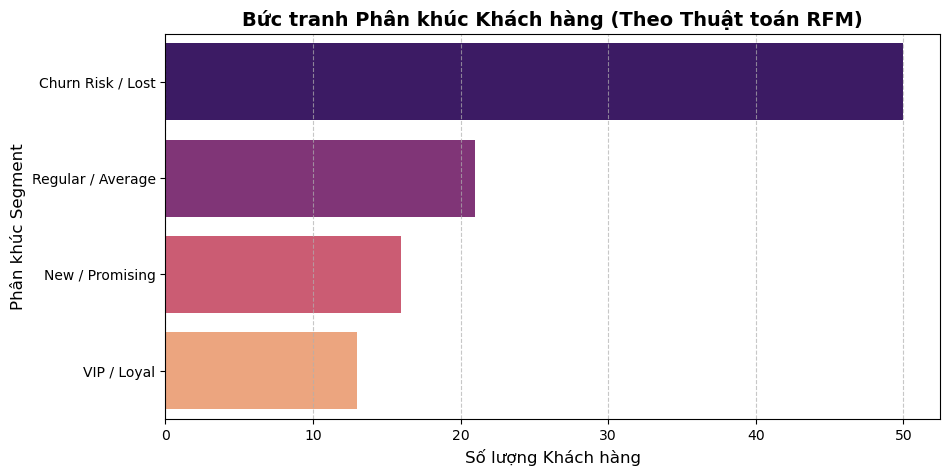

--- Thống kê Số lượng Khách hàng theo Phân Khúc RFM ---


,Số lượng Khách Hàng
Segment,
Churn Risk / Lost,50
Regular / Average,21
New / Promising,16
VIP / Loyal,13


In [58]:

# Trực quan hóa Phân khúc Khách hàng
plt.figure(figsize=(10, 5))
sns.countplot(y='Segment', data=rfm, order=rfm['Segment'].value_counts().index, palette='magma')
plt.title('Bức tranh Phân khúc Khách hàng (Theo Thuật toán RFM)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng Khách hàng', fontsize=12)
plt.ylabel('Phân khúc Segment', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("--- Thống kê Số lượng Khách hàng theo Phân Khúc RFM ---")
display(rfm['Segment'].value_counts().to_frame('Số lượng Khách Hàng'))

### 15. Phân tích Tỷ lệ Giữ chân Khách hàng (Cohort Retention Analysis)
Đánh giá theo các Nhóm Khách Hàng (Cohort - mua lần đầu vào cùng 1 tháng) xem tỷ lệ họ tiếp tục quay lại giao dịch ở các tháng sau là bao nhiêu %."

In [59]:
# Format OrderMonth: YYYY-MM
df_all['OrderMonth'] = df_all['OrderDate'].dt.to_period('M')

# Tìm tháng mua hàng ĐẦU TIÊN của từng Khách hàng (CohortMonth)
df_all['CohortMonth'] = df_all.groupby('CustomerID')['OrderMonth'].transform('min')

# Hàm lấy index ngày tháng
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df_all, 'OrderMonth')
cohort_year, cohort_month = get_date_int(df_all, 'CohortMonth')


In [60]:

# Tính khoảng cách CohortIndex (tháng tuổi quay lại mua hàng)
years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month
df_all['CohortIndex'] = years_diff * 12 + months_diff + 1


In [61]:

# Tạo bảng dữ liệu Cohort
cohort_data = df_all.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')


In [62]:

# Lấy tháng đầu tiên làm base (100%)
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention.index = retention.index.astype(str)


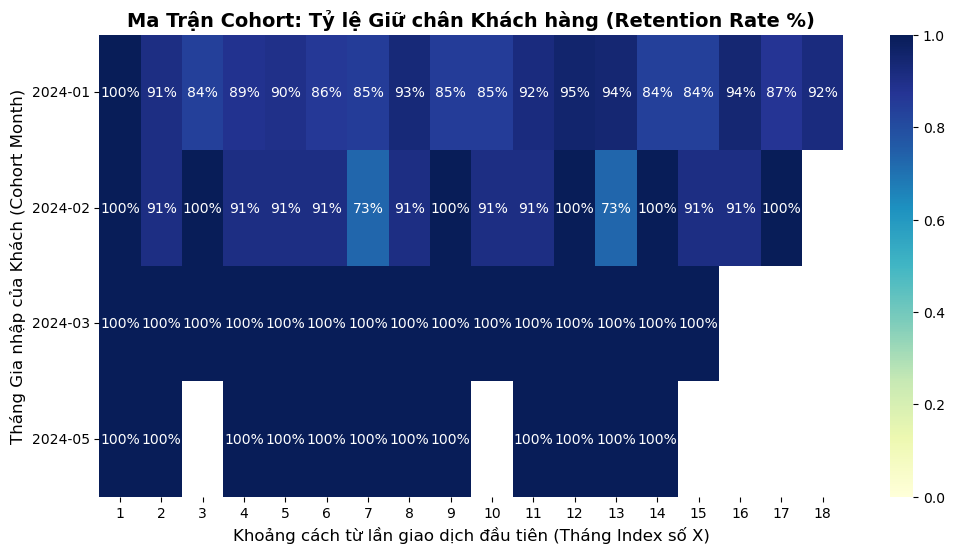

=> Insight: Giữ chân khách hàng dài hạn (tháng 2, tháng 3 trở lên) cho thấy mức độ rớt của ngành Bán lẻ Điện máy / Thiết bị. Do vòng đời sản phẩm dài, tỷ lệ Cohort tháng kế tiếp thường cực kỳ thấp, buộc đội Sales phải có chiến lược Liên tục mở rộng Phễu Khách Mới.


In [63]:

# Vẽ Heatmap Tỷ lệ Giữ chân (Retention Rate)
plt.figure(figsize=(12, 6))
sns.heatmap(data=retention, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0.0, vmax=1.0)
plt.title('Ma Trận Cohort: Tỷ lệ Giữ chân Khách hàng (Retention Rate %)', fontsize=14, fontweight='bold')
plt.xlabel('Khoảng cách từ lần giao dịch đầu tiên (Tháng Index số X)', fontsize=12)
plt.ylabel('Tháng Gia nhập của Khách (Cohort Month)', fontsize=12)
plt.yticks(rotation=0)
plt.show()

print("=> Insight: Giữ chân khách hàng dài hạn (tháng 2, tháng 3 trở lên) cho thấy mức độ rớt của ngành Bán lẻ Điện máy / Thiết bị. Do vòng đời sản phẩm dài, tỷ lệ Cohort tháng kế tiếp thường cực kỳ thấp, buộc đội Sales phải có chiến lược Liên tục mở rộng Phễu Khách Mới.")


### 16. Phân tích Giỏ hàng (Market Basket Analysis - Cross-selling cùng một Hóa Đơn)
Xác định các sản phẩm được Khách Hàng thanh toán ghép trong CÙNG MỘT MÃ ĐƠN (Cart). Đây là kĩ thuật tìm quy luật theo Thuật toán Apriori Basic."

In [66]:
#Kiểm tra xem 1 OrderID có nằm cùng nhiều dòng Sản phẩm (Nhiều Items) không
order_product = df_all.groupby(['OrderID', 'ProductID'])['Quantity'].sum().unstack().fillna(0)

# Chuyển đổi: Order nào có nhặt MẶT HÀNG ĐÓ (Quantity > 0) thì ghi là 1
basket = (order_product > 0).astype(int)

# Lọc các giỏ hàng (OrderID) mua cùng lúc >= 2 mặt hàng trở lên
basket_multi = basket[(basket > 0).sum(axis=1) >= 2]

if basket_multi.empty:
    print("=> ⚠️ Insight Giỏ Hàng: 100% Khách Hàng trong Tập dữ liệu này trong MỖI MÃ HÓA ĐƠN (OrderID) chỉ mua duy nhất 1 LOẠI SẢN PHẨM duy nhất!")
    print("=> Phân tích: Không tồn tại Mua Ghép/Đi cùng nhau trên cùng 1 Hóa đơn.")
    print("=> GIẢI PHÁP: Vậy để ứng dụng Cross-Selling đối với khách Điện Máy ở Data này, Sales phải Tracking ở góc độ (Mua Mặt Hàng A trong Tháng 1, và Tháng 4 mua tiếp Mặt hàng B bằng OrderID khác). Giống cách ta khai thác tại Section 10 khi kiểm tra chéo CustomerID.")
else:
    # Nếu có mua ghép trong cùng 1 Bill, tính ma trận Dot Product (Xác suất) 
    frequent_items = basket_multi.T.dot(basket_multi)
    np.fill_diagonal(frequent_items.values, 0)
    
    # Hiển thị Top các cặp mua cùng nhau
    pairs = frequent_items.unstack().reset_index()
    pairs.columns = ['Product_A', 'Product_B', 'Lượt_Mua_Chéo_Trong_1_Bill']
    pairs = pairs.sort_values('Lượt_Mua_Chéo_Trong_1_Bill', ascending=False)
    
    # Lọc bỏ cặp bị lặp 2 chiều (ví dụ A-B bằng B-A)
    # Tự định danh chuỗi để drop trùng
    pairs['PairID'] = pairs.apply(lambda row: tuple(sorted([row['Product_A'], row['Product_B']])), axis=1)
    pairs = pairs.drop_duplicates(subset=['PairID']).drop(columns=['PairID'])
    
    print("--- TOP ĐIỂM SÁNG: CÁC mặt hàng CÙNG CHUI VÀO GIỎ HÀNG 1 LÚC (Trên 1 Hóa Đơn) ---")
    display(pairs[pairs['Lượt_Mua_Chéo_Trong_1_Bill'] > 0].head(10))
    

=> ⚠️ Insight Giỏ Hàng: 100% Khách Hàng trong Tập dữ liệu này trong MỖI MÃ HÓA ĐƠN (OrderID) chỉ mua duy nhất 1 LOẠI SẢN PHẨM duy nhất!
=> Phân tích: Không tồn tại Mua Ghép/Đi cùng nhau trên cùng 1 Hóa đơn.
=> GIẢI PHÁP: Vậy để ứng dụng Cross-Selling đối với khách Điện Máy ở Data này, Sales phải Tracking ở góc độ (Mua Mặt Hàng A trong Tháng 1, và Tháng 4 mua tiếp Mặt hàng B bằng OrderID khác). Giống cách ta khai thác tại Section 10 khi kiểm tra chéo CustomerID.


### 17. Theo dõi Suy thoái Biên lợi nhuận (Profit Margin Erosion Tracker)
Trực quan hóa sự 'Đánh Đổi' (Trade-off) giữa Doanh Thu kiếm được và Biên Lợi Nhuận qua các Tháng, giúp sếp Tài chính phát hiện nếu việc Bơm Doanh thu có đang hi sinh dòng tiền Lõi hay không."

Text(0, 0.5, 'Bề cực chìm: Biên Lợi Nhuận Gộp (%)')

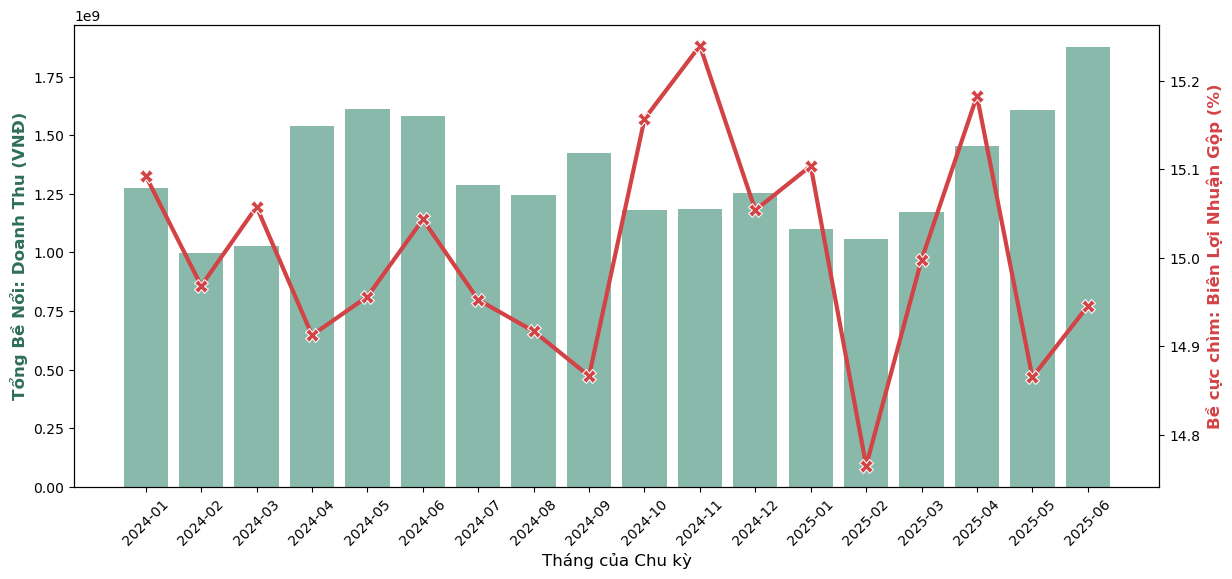

In [68]:
# Gom nhóm tính toán theo Tháng (OrderMonth)
monthly_perf = df_all.groupby('OrderMonth').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

# Tính Profit Margin
monthly_perf['Profit_Margin_%'] = (monthly_perf['Total_Profit'] / monthly_perf['Total_Revenue']) * 100
monthly_perf['OrderMonth_Str'] = monthly_perf['OrderMonth'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Trục 1 (Cột): Biểu diễn Tổng Doanh thu từng tháng
sns.barplot(data=monthly_perf, x='OrderMonth_Str', y='Total_Revenue', color='#72bba6', alpha=0.9, ax=ax1)
ax1.set_ylabel('Tổng Bề Nổi: Doanh Thu (VNĐ)', color='#2e6e5b', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tháng của Chu kỳ', fontsize=12)
plt.xticks(rotation=45)

# Trục 2 (Đường): Biểu diễn Biên lợi nhuận (%) để xem nó có bị lõm - Erosion hay không?
ax2 = ax1.twinx()
sns.lineplot(data=monthly_perf, x='OrderMonth_Str', y='Profit_Margin_%', color='#d34346', marker='X', markersize=10, linewidth=3, ax=ax2)
ax2.set_ylabel('Bề cực chìm: Biên Lợi Nhuận Gộp (%)', color='#d34346', fontsize=12, fontweight='bold')


C:\Users\THANH HIEN\AppData\Local\Temp\ipykernel_39416\3932751763.py:7: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


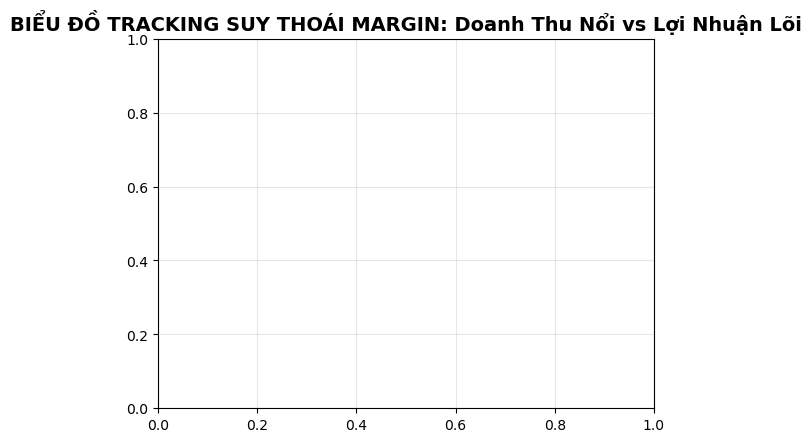

=> Insight từ Tracking Profit Margin Erosion:
1. Nếu thấy Doanh thu (Column) tăng ĐỘT BIẾN lên đỉnh, nhưng Lợi Nhuận Gộp (Line đỏ) lại cắm đầu gãy sâu: Dấu hiệu CẢNH BÁO của việc công ty đang bán Phá Giá (Flash Sale mùa vụ) quá lạm dụng, đánh đổi Lợi nhuận cốt lõi (Gross Profit) chỉ để lấy Doanh số.
2. Đội ngũ Quản trị/Pricing cần dùng Biểu đồ này họp định kỳ hàng Tháng để có chính sách ngắt Giá Sàn Kịp thời!


In [ ]:

# Định hình độ rải trục (%) để đường đi gãy khúc rõ ràng hơn và ko bị méo
min_margin = monthly_perf['Profit_Margin_%'].min() * 0.95
max_margin = monthly_perf['Profit_Margin_%'].max() * 1.05
ax2.set_ylim([min_margin, max_margin])

plt.title('BIỂU ĐỒ TRACKING SUY THOÁI MARGIN: Doanh Thu Nổi vs Lợi Nhuận Lõi', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()

print("=> Insight từ Tracking Profit Margin Erosion:")
print("1. Nếu thấy Doanh thu (Column) tăng ĐỘT BIẾN lên đỉnh, nhưng Lợi Nhuận Gộp (Line đỏ) lại cắm đầu gãy sâu: Dấu hiệu CẢNH BÁO của việc công ty đang bán Phá Giá (Flash Sale mùa vụ) quá lạm dụng, đánh đổi Lợi nhuận cốt lõi (Gross Profit) chỉ để lấy Doanh số.")
print("2. Đội ngũ Quản trị/Pricing cần dùng Biểu đồ này họp định kỳ hàng Tháng để có chính sách ngắt Giá Sàn Kịp thời!")

### 18. Khám phá Sản phẩm Yêu thích của Khách VIP & Điểm mặt Sản phẩm Kém Hiệu quả 
Phân tích chi tiết hành vi mua hàng của Top 3 Khách hàng mang lại Doanh thu lớn nhất và tìm ra Top 10 sản phẩm bán chậm nhất để có phương án xả hàng tồn."

In [72]:
# 18.1 Tìm Top 3 Khách hàng mang lại doanh thu cao nhất và 3 Sản phẩm họ thường mua nhất
print("--- 1. TOP 3 KHÁCH HÀNG VIP VÀ SẢN PHẨM HỌ MUA NHIỀU NHẤT ---")
# Lấy ra Top 3 CustomerID có Total Revenue cao nhất
top3_vip_df = df_all.groupby('CustomerID')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False).head(3)
top3_vip = top3_vip_df['CustomerID'].tolist()

for vip in top3_vip:
    # Lọc dữ liệu mua hàng của phân khúc VIP này
    vip_data = df_all[df_all['CustomerID'] == vip]
    
    # Tìm Top 3 sản phẩm mua nhiều nhất theo số lượng (Quantity)
    fav_products = vip_data.groupby('ProductID').agg(
        Total_Quantity=('Quantity', 'sum'),
        Total_Revenue=('Revenue', 'sum')
    ).reset_index().sort_values(by='Total_Quantity', ascending=False).head(3)
    
    # Lấy doanh thu của VIP này
    vip_revenue = top3_vip_df[top3_vip_df['CustomerID']==vip]['Revenue'].values[0]
    print(f"\\n👉 Khách hàng VIP: {vip} | Tổng Doanh thu mang lại: {vip_revenue:,.0f} VNĐ")
    display(fav_products)


--- 1. TOP 3 KHÁCH HÀNG VIP VÀ SẢN PHẨM HỌ MUA NHIỀU NHẤT ---
\n👉 Khách hàng VIP: C032 | Tổng Doanh thu mang lại: 386,437,000 VNĐ


,ProductID,Total_Quantity,Total_Revenue
10,MW-SHARP-23,9,21238000.0
1,AC-15HP-CS,8,89285000.0
11,RC-SHARP-20,7,12783000.0


\n👉 Khách hàng VIP: C099 | Tổng Doanh thu mang lại: 360,171,000 VNĐ


,ProductID,Total_Quantity,Total_Revenue
2,AC-1HP-CP,9,51368000.0
7,KTL-ELUX-17,8,6000000.0
1,AC-15HP-CS,7,76244000.0


\n👉 Khách hàng VIP: C001 | Tổng Doanh thu mang lại: 354,106,000 VNĐ


,ProductID,Total_Quantity,Total_Revenue
3,AC-1HP-CS,8,71242000.0
0,AC-15HP-CP,7,53998000.0
14,VAC-PANA-16,7,17157000.0


\n\n--- 2. TOP 10 SẢN PHẨM BÁN CHẬM NHẤT (SẢN PHẨM Ế NHẤT) ---


,ProductID,Total_Quantity,Total_Revenue,Unique_Customers
0,WM-AQUA-9,193,1.636354e+09,77
1,AIR-PURI-60,214,1.544210e+09,83
2,VAC-ELUX-18,215,4.698910e+08,79
3,VAC-PANA-16,236,5.923710e+08,80
4,AIR-PURI-40,241,1.085357e+09,84
5,WM-PANA-11,247,2.695064e+09,88
6,WH-ROSSI-20,271,5.723210e+08,89
7,MW-SHARP-23,280,6.417870e+08,79
8,RC-SHARP-20,285,5.407040e+08,85
9,AC-15HP-CS,287,3.159229e+09,89


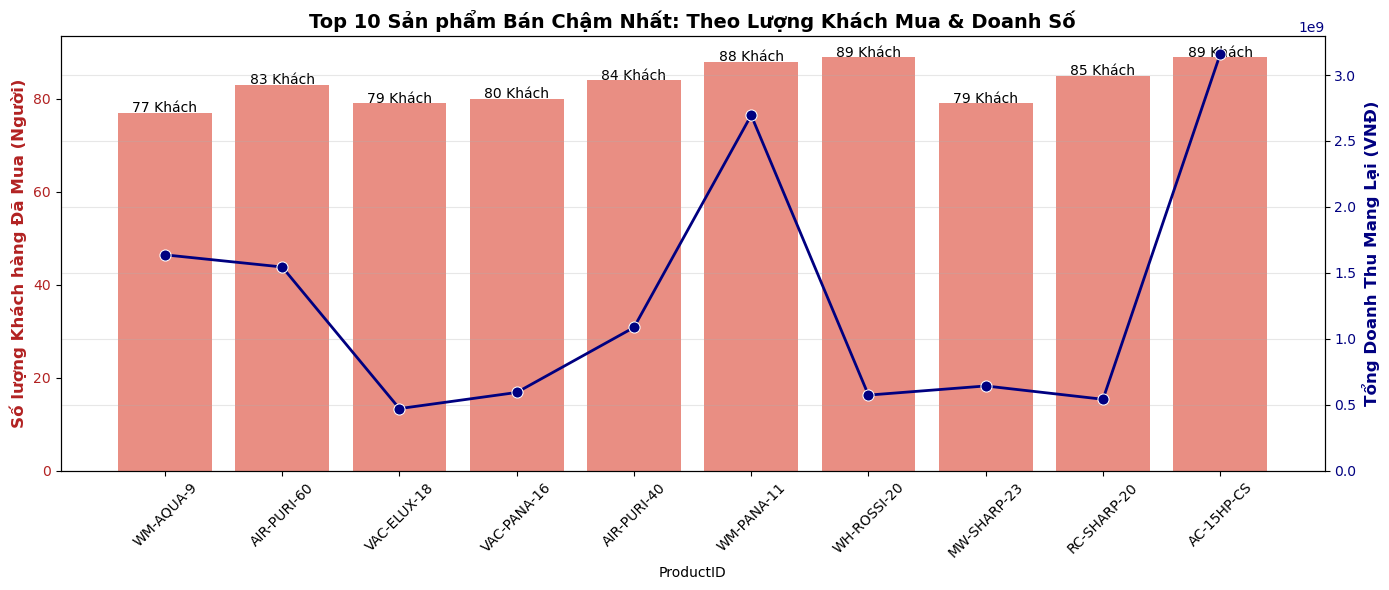

=> Mách nước cho sếp Sales & Marketing từ Nhóm Hàng Ế (Long-tail):
- Những sản phẩm này có Số lượng người mua (Unique Customers) cực kỳ hữu hạn (có món chỉ 1-2 người mua rải rác). Doanh thu đóng góp siêu nhỏ.
- Đề xuất Hành động: Phải áp dụng ngay chiến lược Bundle (Bán Combo kẹp sản phẩm ế kèm chung với nhóm Hàng Điểm Sáng / Bán Chạy) để tống khứ bớt tồn kho, giải phóng dòng tiền. Nếu Model hàng đã quá cũ (Clearance), phải xả lỗ (Loss Leader) dứt điểm để lấy chỗ trong Kho mạn cho hàng mùa mới.


In [75]:

# 18.2 Top 10 sản phẩm ít được mua nhất
print("\\n\\n--- 2. TOP 10 SẢN PHẨM BÁN CHẬM NHẤT (SẢN PHẨM Ế NHẤT) ---")

# Tính tổng Quantity, Revenue, và Unique Customers cho TỪNG sản phẩm trên toàn bộ Data
product_perf = df_all.groupby('ProductID').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Unique_Customers=('CustomerID', 'nunique')
).reset_index()

# Lấy 10 sản phẩm có Total_Quantity NHỎ NHẤT
bottom_10_products = product_perf.sort_values(by=['Total_Quantity', 'Total_Revenue'], ascending=[True, True]).head(10).reset_index(drop=True)

display(bottom_10_products)

# Trực quan hóa Top 10 Hàng Ế
fig, ax1 = plt.subplots(figsize=(14, 6))

# Cột: Số lượng khách hàng đã mua
sns.barplot(data=bottom_10_products, x='ProductID', y='Unique_Customers', color='salmon', ax=ax1)
ax1.set_ylabel('Số lượng Khách hàng Đã Mua (Người)', color='firebrick', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='firebrick')
plt.xticks(rotation=45)

# Hiển thị text nhãn số lượng Khách hàng mua
for i, v in enumerate(bottom_10_products['Unique_Customers']):
    ax1.text(i, v + 0.1, f'{v} Khách', color='black', ha='center', fontsize=10)

# Đường: Doanh thu
ax2 = ax1.twinx()
sns.lineplot(data=bottom_10_products, x='ProductID', y='Total_Revenue', color='navy', marker='o', linewidth=2, markersize=8, ax=ax2)
ax2.set_ylabel('Tổng Doanh Thu Mang Lại (VNĐ)', color='navy', fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor='navy')
ax2.set_ylim(bottom=-1000)

plt.title('Top 10 Sản phẩm Bán Chậm Nhất: Theo Lượng Khách Mua & Doanh Số', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()

print("=> Mách nước cho sếp Sales & Marketing từ Nhóm Hàng Ế (Long-tail):")
print("- Những sản phẩm này có Số lượng người mua (Unique Customers) cực kỳ hữu hạn (có món chỉ 1-2 người mua rải rác). Doanh thu đóng góp siêu nhỏ.")
print("- Đề xuất Hành động: Phải áp dụng ngay chiến lược Bundle (Bán Combo kẹp sản phẩm ế kèm chung với nhóm Hàng Điểm Sáng / Bán Chạy) để tống khứ bớt tồn kho, giải phóng dòng tiền. Nếu Model hàng đã quá cũ (Clearance), phải xả lỗ (Loss Leader) dứt điểm để lấy chỗ trong Kho mạn cho hàng mùa mới.")

In [76]:
# 📖 DATA STORYTELLING: Bức Tranh Toàn Cảnh Hoạt Động Bán Lẻ Điện Máy (2024-2025)

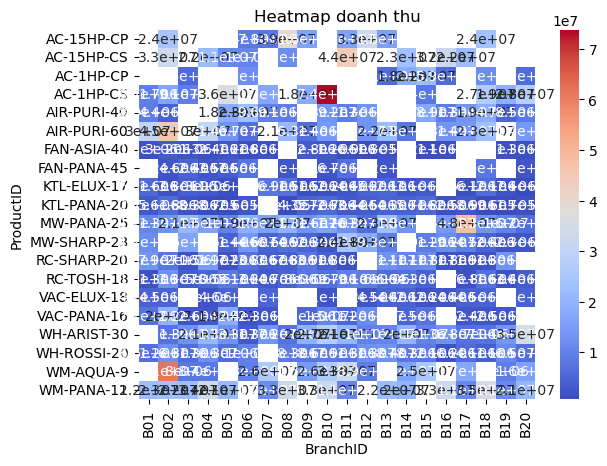

In [7]:
import pandas as pd
df = pd.read_csv('Sales_Q1_2024_VN.csv')
pivot = df.pivot_table(
    values="Revenue",
    index="ProductID",
    columns="BranchID",
    aggfunc="sum"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Heatmap doanh thu")
plt.show()

In [9]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['Day'] = df['OrderDate'].dt.day
df['DayOfWeek'] = df['OrderDate'].dt.day_name()
df['Quarter'] = df['OrderDate'].dt.quarter

<Axes: xlabel='Month', ylabel='Revenue'>

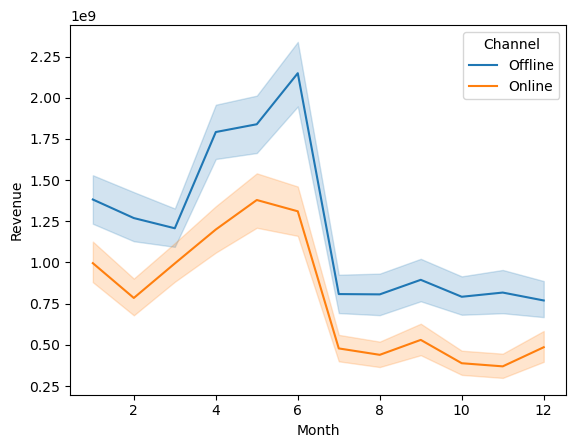

In [10]:
sns.lineplot(
    data=df,
    x="Month",
    y="Revenue",
    hue="Channel",
    estimator="sum"
)

<Axes: xlabel='Month', ylabel='DayOfWeek'>

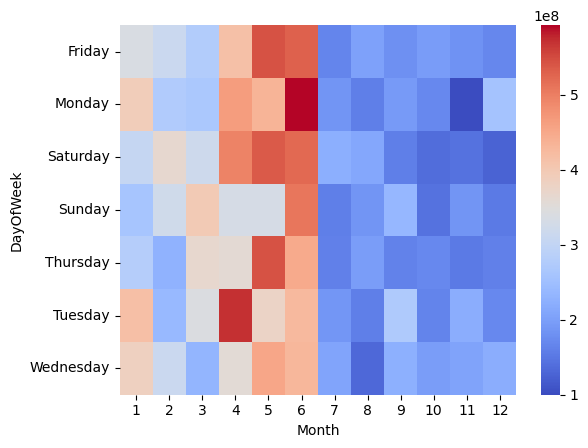

In [11]:
pivot = df.pivot_table(
    values="Revenue",
    index="DayOfWeek",
    columns="Month",
    aggfunc="sum"
)

sns.heatmap(pivot, cmap="coolwarm")

<Axes: xlabel='Quantity', ylabel='Revenue'>

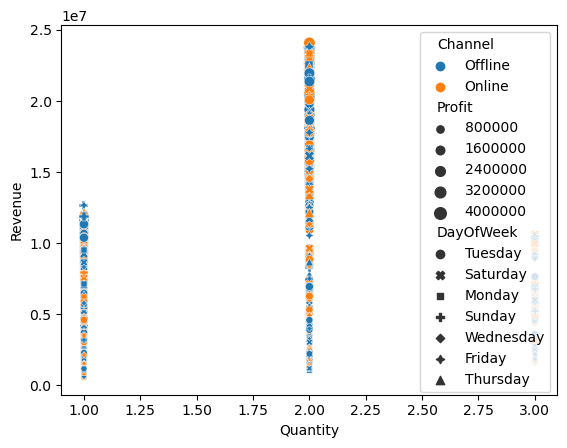

In [12]:
sns.scatterplot(
    data=df,
    x="Quantity",
    y="Revenue",
    hue="Channel",
    size="Profit",
    style="DayOfWeek"
)

<Axes: xlabel='DayOfWeek', ylabel='Revenue'>

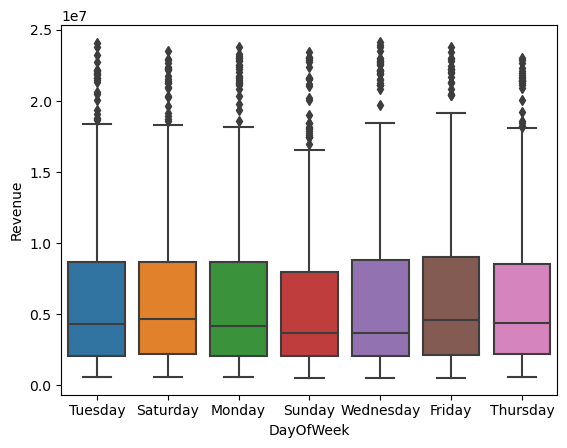

In [13]:
sns.boxplot(
    data=df,
    x="DayOfWeek",
    y="Revenue"
)

c:\Users\THANH HIEN\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


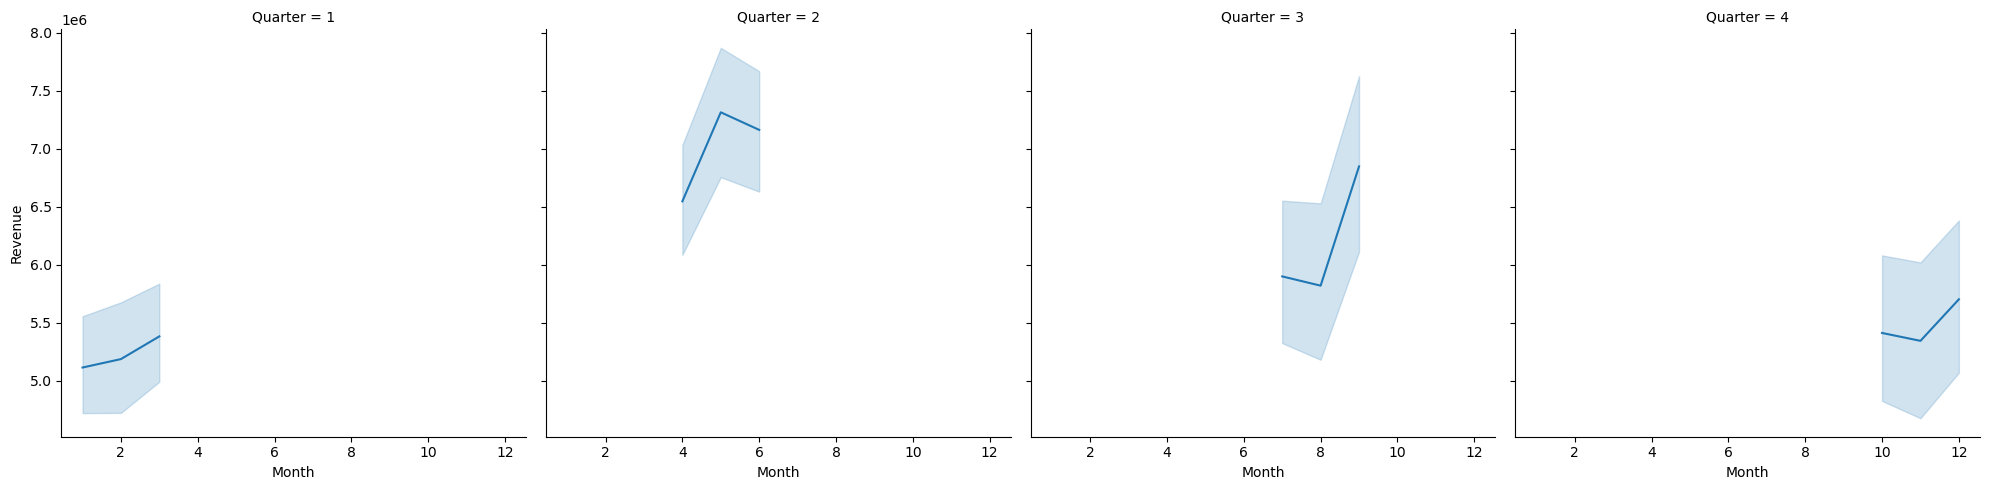

In [14]:
sns.relplot(
    data=df,
    x="Month",
    y="Revenue",
    col="Quarter",
    kind="line"
)

### Xu hướng doanh thu

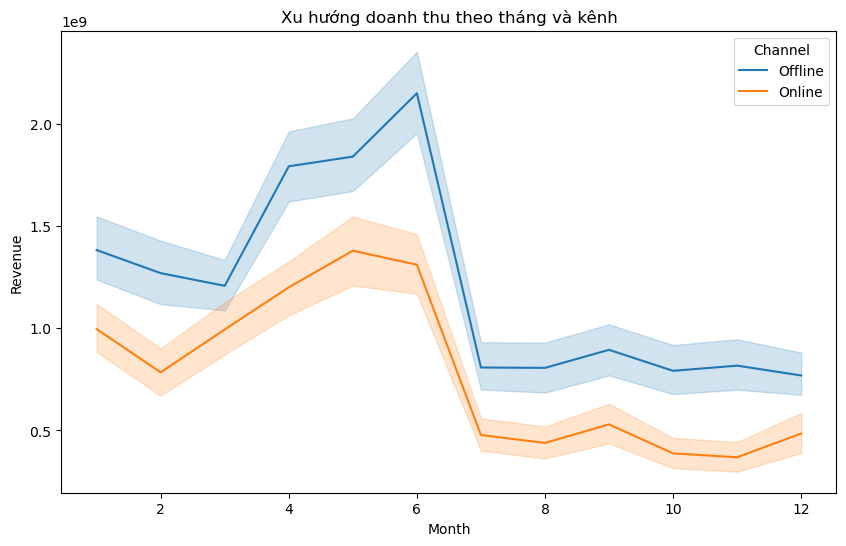

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Month'] = df['OrderDate'].dt.month

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="Month",
    y="Revenue",
    hue="Channel",
    estimator="sum"
)

plt.title("Xu hướng doanh thu theo tháng và kênh")
plt.show()

### Doanh thu với lợi nhuận 

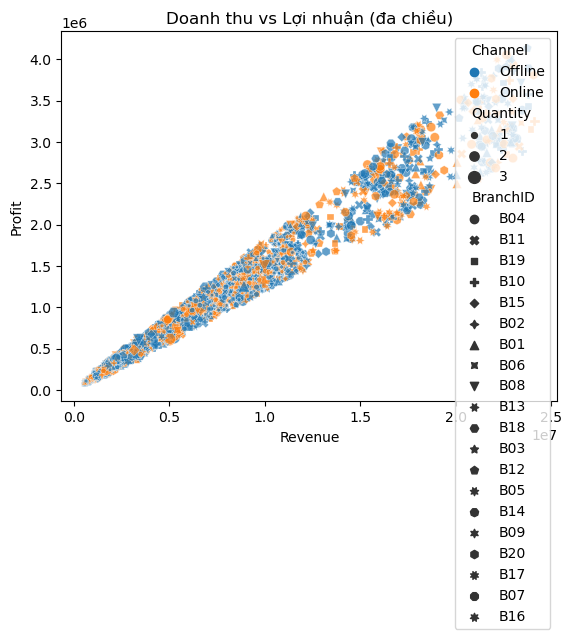

In [16]:
sns.scatterplot(
    data=df,
    x="Revenue",
    y="Profit",
    hue="Channel",
    size="Quantity",
    style="BranchID",
    alpha=0.7
)

plt.title("Doanh thu vs Lợi nhuận (đa chiều)")
plt.show()

#### => Revenue cao nhưng profit thấp


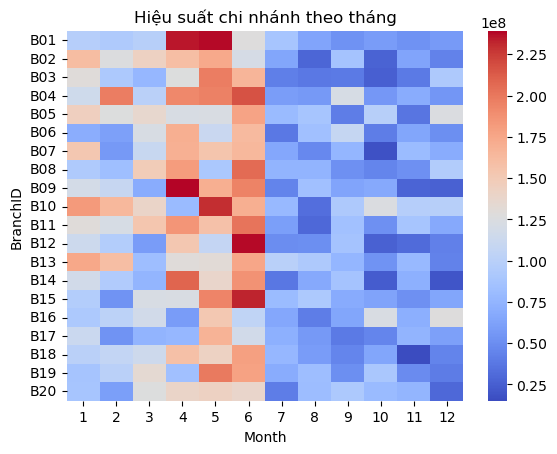

In [17]:
df['DayOfWeek'] = df['OrderDate'].dt.day_name()

pivot = df.pivot_table(
    values="Revenue",
    index="BranchID",
    columns="Month",
    aggfunc="sum"
)

sns.heatmap(pivot, cmap="coolwarm")
plt.title("Hiệu suất chi nhánh theo tháng")
plt.show()

### Cơ cấu doanh thu theo kênh

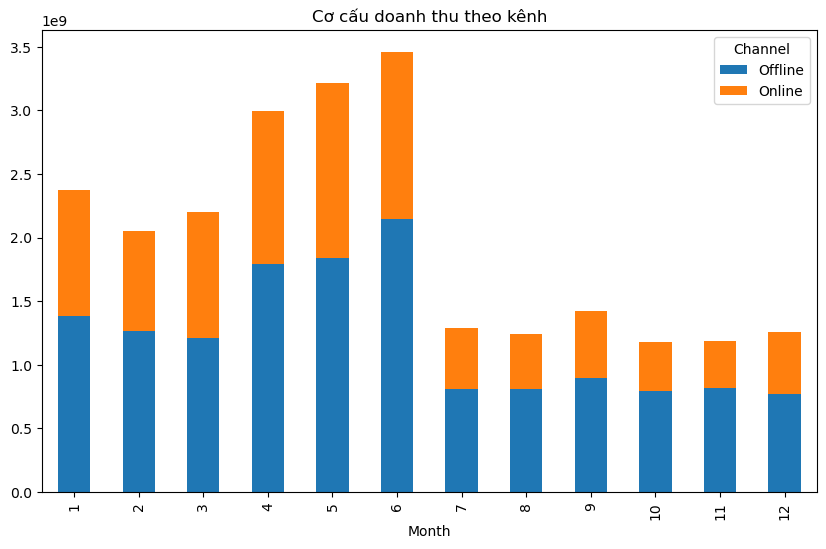

In [18]:
pivot = df.pivot_table(
    values="Revenue",
    index="Month",
    columns="Channel",
    aggfunc="sum"
)

pivot.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Cơ cấu doanh thu theo kênh")
plt.show()

### Top sản phẩm

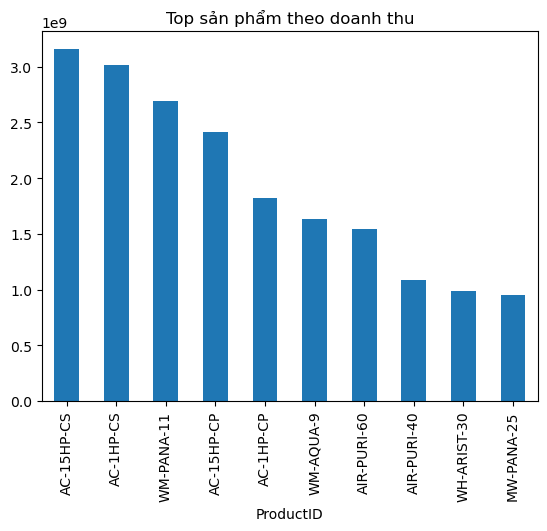

In [19]:
top_products = df.groupby("ProductID")["Revenue"].sum().nlargest(10)

top_products.plot(kind="bar")
plt.title("Top sản phẩm theo doanh thu")
plt.show()

### Hành vi theo ngày

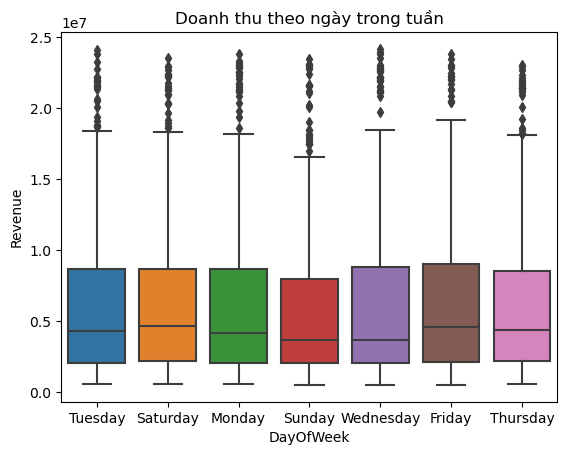

In [20]:
sns.boxplot(
    data=df,
    x="DayOfWeek",
    y="Revenue"
)

plt.title("Doanh thu theo ngày trong tuần")
plt.show()

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
files = [
    "Sales_Q1_2024_VN.csv",
    "Sales_Q2_2024_VN.csv",
    "Sales_Q3_2024_VN.csv",
    "Sales_Q4_2024_VN.csv",
    "Sales_Q1_2025_VN.csv",
    "Sales_Q2_2025_VN.csv"
]

df = pd.concat([pd.read_csv(f) for f in files])

In [5]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [6]:
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year

In [7]:
print(df.head())
print(df.columns)

         OrderID  OrderDate    ProductID CustomerID BranchID  Quantity  \
0  2024-Q1-00001 2024-01-02   WM-PANA-11       C034      B04         2   
1  2024-Q1-00002 2024-02-10  WH-ARIST-30       C003      B11         2   
2  2024-Q1-00003 2024-01-22  WH-ROSSI-20       C044      B19         2   
3  2024-Q1-00004 2024-03-17  FAN-ASIA-40       C001      B10         3   
4  2024-Q1-00005 2024-02-07    WM-AQUA-9       C026      B19         1   

      Revenue     Profit  Channel  Month  Year  
0  23204000.0  3041000.0  Offline      1  2024  
1   6692000.0  1160000.0   Online      2  2024  
2   4410000.0   696000.0   Online      1  2024  
3   1601000.0   208000.0  Offline      3  2024  
4   9045000.0  1481000.0  Offline      2  2024  
Index(['OrderID', 'OrderDate', 'ProductID', 'CustomerID', 'BranchID',
       'Quantity', 'Revenue', 'Profit', 'Channel', 'Month', 'Year'],
      dtype='object')


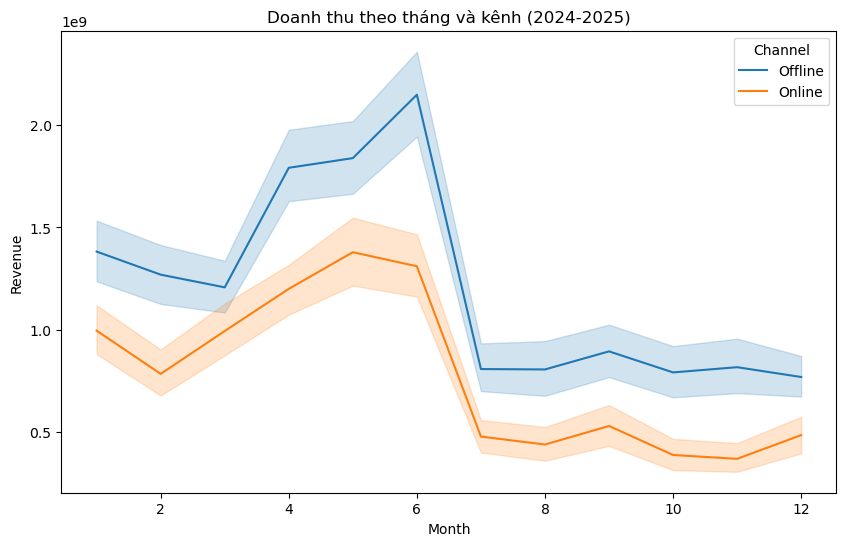

In [8]:
# df['Month'] = df['OrderDate'].dt.month
# df['Year'] = df['OrderDate'].dt.year

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="Month",
    y="Revenue",
    hue="Channel",
    estimator="sum"
)

plt.title("Doanh thu theo tháng và kênh (2024-2025)")
plt.show()

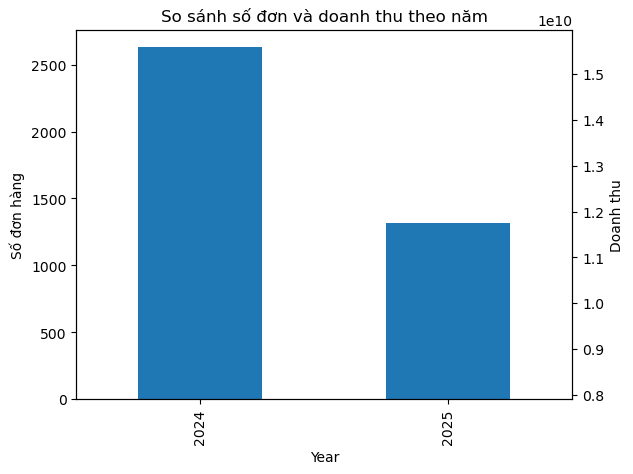

In [9]:
orders = df.groupby("Year")["OrderID"].nunique()
revenue = df.groupby("Year")["Revenue"].sum()

fig, ax1 = plt.subplots()

orders.plot(kind='bar', ax=ax1)
ax1.set_ylabel("Số đơn hàng")

ax2 = ax1.twinx()
revenue.plot(kind='line', ax=ax2)
ax2.set_ylabel("Doanh thu")

plt.title("So sánh số đơn và doanh thu theo năm")
plt.show()

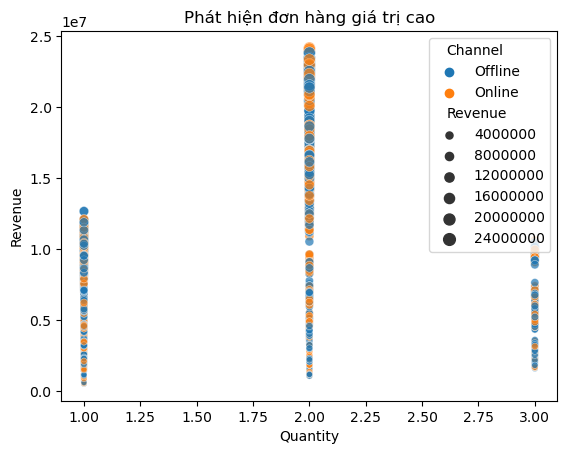

In [10]:
sns.scatterplot(
    data=df,
    x="Quantity",
    y="Revenue",
    hue="Channel",
    size="Revenue",
    alpha=0.7
)

plt.title("Phát hiện đơn hàng giá trị cao")
plt.show()

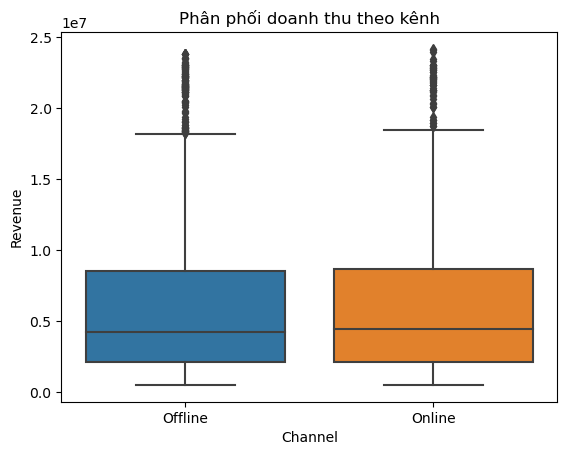

In [11]:
sns.boxplot(
    data=df,
    x="Channel",
    y="Revenue"
)

plt.title("Phân phối doanh thu theo kênh")
plt.show()

In [1]:
import matplotlib.pyplot as plt

# tổng hợp theo năm
multi = df.groupby('Year').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'OrderID': 'nunique'
}).reset_index()

plt.scatter(
    multi['Revenue'],
    multi['Profit'],
    s=multi['OrderID']*10,   # size
)

for i in range(len(multi)):
    plt.text(multi['Revenue'][i], multi['Profit'][i], str(multi['Year'][i]))

plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.title('Multi-dimensional Analysis (Revenue, Profit, Orders)')
plt.show()

NameError: name 'df' is not defined